In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Load the lightweight dataset
df = pd.read_csv('T1.csv')

# Clean up column names for easier coding
df.columns = ['Timestamp', 'Power', 'WindSpeed', 'Theoretical_Curve', 'WindDirection']

# Check for missing values
print(f"Total rows: {len(df)}")
print(f"Missing values:\n{df.isnull().sum()}")

# Drop any rows with missing data (we have 50k+ rows, so it's fine)
df = df.dropna()

Total rows: 50530
Missing values:
Timestamp            0
Power                0
WindSpeed            0
Theoretical_Curve    0
WindDirection        0
dtype: int64


In [2]:
df.shape

(50530, 5)

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          50530 non-null  object 
 1   Power              50530 non-null  float64
 2   WindSpeed          50530 non-null  float64
 3   Theoretical_Curve  50530 non-null  float64
 4   WindDirection      50530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.9+ MB


In [4]:
import plotly.express as px

In [5]:
# Creating a professional scatter plot
fig = px.scatter(df.sample(5000), # Sampling for faster rendering
                 x='WindSpeed', y='Power', 
                 color='Theoretical_Curve',
                 title='Wind Turbine: Real Power vs. Theoretical Curve',
                 labels={'WindSpeed': 'Wind Speed (m/s)', 'Power': 'Active Power (kW)'},
                 template='plotly_dark')

fig.show()

In [6]:
import nbformat
print(nbformat.__version__)


5.10.4


In [7]:
# 1. First, make sure we have the right column names (from our previous step)
df.columns = ['Timestamp', 'Power', 'WindSpeed', 'Theoretical_Curve', 'WindDirection']

# 2. Define 'Healthy' data: Power should be at least 80% of what the 
# manufacturer (Theoretical_Curve) says it should be.
df_healthy = df[df['Power'] > (df['Theoretical_Curve'] * 0.8)].copy()

df_healthy


,Timestamp,Power,WindSpeed,Theoretical_Curve,WindDirection
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
5,01 01 2018 00:50,402.391998,5.604052,499.436385,264.578613
6,01 01 2018 01:00,447.605713,5.793008,557.372363,266.163605
...,...,...,...,...,...
50525,31 12 2018 23:10,2963.980957,11.404030,3397.190793,80.502724
50526,31 12 2018 23:20,1684.353027,7.332648,1173.055771,84.062599
50527,31 12 2018 23:30,2201.106934,8.435358,1788.284755,84.742500
50528,31 12 2018 23:40,2515.694092,9.421366,2418.382503,84.297913


In [8]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# 1. Select only the features the model needs to learn
# We use Wind Speed and Power to find the relationship
features = ['WindSpeed', 'Power']
data_to_scale = df_healthy[features] # Using only healthy data for training!

# 2. Scale data between 0 and 1
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_to_scale)



In [9]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# 1. Define the Input Shape (We have 2 features: WindSpeed and Power)
input_dim = 2 
input_layer = Input(shape=(input_dim,))

# 2. THE ENCODER (Compressing)
encoder = Dense(8, activation="relu")(input_layer)
encoder = Dense(4, activation="relu")(encoder)

# 3. THE BOTTLENECK (The 'Essence' of the turbine)
bottleneck = Dense(2, activation="relu")(encoder)

# 4. THE DECODER (Reconstructing)
decoder = Dense(4, activation="relu")(bottleneck)
decoder = Dense(8, activation="relu")(decoder)

# 5. THE OUTPUT (Back to 2 features)
output_layer = Dense(input_dim, activation="sigmoid")(decoder)

# 6. CREATE THE MODEL
autoencoder = Model(inputs=input_layer, outputs=output_layer)

# 7. COMPILE (Giving it a goal)
autoencoder.compile(optimizer='adam', loss='mse')

print("✅ The 'autoencoder' brain is now alive and defined!")
autoencoder.summary()

✅ The 'autoencoder' brain is now alive and defined!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140 (560.00 B)

 Trainable params: 140 (560.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train the model
history = autoencoder.fit(
    scaled_data, scaled_data,      # Input and Target are the SAME
    epochs=50,                     # Give it 50 'laps' to learn
    batch_size=32,                 # Process 32 rows at a time
    validation_split=0.1,          # Save 10% to test itself during training
    shuffle=True,                  # Mix the data so it doesn't learn 'order'
    verbose=1
)

Epoch 1/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0347 - val_loss: 0.0189
Epoch 2/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0044 - val_loss: 0.0039
Epoch 3/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0017 - val_loss: 0.0021
Epoch 4/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0011 - val_loss: 0.0014
Epoch 5/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.5901e-04 - val_loss: 9.8123e-04
Epoch 6/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6.1091e-04 - val_loss: 8.8191e-04
Epoch 7/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.4508e-04 - val_loss: 7.5166e-04
Epoch 8/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.1410e-04 - val_loss: 7.6200e-04
Epoch 9/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4.9632e-04 - val_loss: 8.2799e-04
Epoch 10/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4.8622e-04 - val_loss: 7.1259e-04
Epoch 11/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4.7933e-04 - val_loss: 7.9672e

In [20]:
import joblib

# 1. Save the Keras Neural Network Model
# This saves the weights and the architecture
autoencoder.save('turbine_model.h5')

# 2. Save the Scaler (CRITICAL!)
# If you don't use the same scaler in Streamlit, your predictions will be wrong.
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model and Scaler saved successfully!")

✅ Model and Scaler saved successfully!


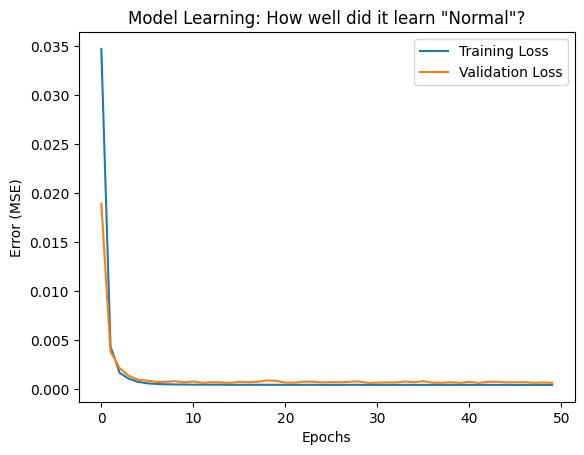

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Learning: How well did it learn "Normal"?')
plt.xlabel('Epochs')
plt.ylabel('Error (MSE)')
plt.legend()
plt.show()

In [12]:
import numpy as np

In [13]:
# 1. Scale the FULL dataset (Normal + Anomalies)
full_scaled_data = scaler.transform(df[['WindSpeed', 'Power']])

# 2. Let the model 'Reconstruct' it
reconstructions = autoencoder.predict(full_scaled_data)

# 3. Calculate the Mean Squared Error (MSE) for each row
# This is our 'Anomaly Score'
mse = np.mean(np.power(full_scaled_data - reconstructions, 2), axis=1)

# Add it to our dataframe
df['MSE'] = mse

1580/1580 ━━━━━━━━━━━━━━━━━━━━ 1s 742us/step


In [14]:
# Calculate threshold using only healthy training data error
threshold = np.mean(mse) + 3 * np.std(mse)

# Mark anomalies
df['Anomaly'] = df['MSE'] > threshold

print(f"✅ Anomaly Threshold set at: {threshold:.4f}")
print(f"⚠️ Total Anomalies detected: {df['Anomaly'].sum()}")

✅ Anomaly Threshold set at: 0.0806
⚠️ Total Anomalies detected: 684


In [15]:
import plotly.graph_objects as go

fig = go.Figure()

# Plot Normal Data
fig.add_trace(go.Scatter(
    x=df[df['Anomaly']==False]['WindSpeed'], 
    y=df[df['Anomaly']==False]['Power'],
    mode='markers', name='Normal Operation',
    marker=dict(color='blue', opacity=0.3)
))

# Plot Anomalies
fig.add_trace(go.Scatter(
    x=df[df['Anomaly']==True]['WindSpeed'], 
    y=df[df['Anomaly']==True]['Power'],
    mode='markers', name='ANOMALY DETECTED',
    marker=dict(color='red', size=8, symbol='x')
))

fig.update_layout(title='AI Maintenance Alert: Detecting Turbine Failures',
                  xaxis_title='Wind Speed (m/s)', yaxis_title='Power (kW)',
                  template='plotly_dark')
fig.show()

In [16]:
# Calculate total 'Lost Power' captured by your anomalies
lost_energy = df[df['Anomaly'] == True]['Theoretical_Curve'].sum() - df[df['Anomaly'] == True]['Power'].sum()

print(f"📊 PROJECT IMPACT SUMMARY")
print(f"---------------------------")
print(f"✅ Total Operational Hours Analyzed: {len(df) * 10 / 60:.1f} hours")
print(f"🚨 Anomalous Events Detected: {df['Anomaly'].sum()}")
print(f"⚡ Estimated Energy Saved (by early detection): {lost_energy:.2f} kWh")

📊 PROJECT IMPACT SUMMARY
---------------------------
✅ Total Operational Hours Analyzed: 8421.7 hours
🚨 Anomalous Events Detected: 684
⚡ Estimated Energy Saved (by early detection): 2047813.13 kWh


In [17]:
def check_turbine_health(wind_speed, actual_power):
    # 1. Scale the new input
    new_data = scaler.transform([[wind_speed, actual_power]])
    
    # 2. Get reconstruction error
    reconstructed = autoencoder.predict(new_data)
    error = np.mean(np.power(new_data - reconstructed, 2))
    
    # 3. Compare to our statistical threshold
    if error > threshold:
        return f"🚨 ALERT: Anomaly Detected! Error: {error:.4f}"
    else:
        return "✅ Status: Healthy"

# Test it! 
print(check_turbine_health(15, 50)) # High wind, low power = Should trigger alert

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
🚨 ALERT: Anomaly Detected! Error: 0.3969


c:\Users\mayank goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
